In [1]:
%%capture --no-stderr
%pip install -U langchain_ollama langgraph langchain_core

In [2]:
import os, getpass

def _set_env(var: str):
    # Check if the variable is set in the OS environment
    env_value = os.environ.get(var)
    if not env_value:
        # If not set, prompt the user for input
        env_value = getpass.getpass(f"{var}: ")
    
    # Set the environment variable for the current process
    os.environ[var] = env_value

_set_env("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "langchain-academy"

In [3]:
import uuid
from langgraph.store.memory import InMemoryStore
in_memory_store = InMemoryStore()

In [4]:
# Namespace for the memory to save
user_id = "1"
namespace_for_memory = (user_id, "memories")

# Save a memory to namespace as key and value
key = str(uuid.uuid4())

# The value needs to be a dictionary  
value = {"food_preference" : "I like pizza"}

# Save the memory
in_memory_store.put(namespace_for_memory, key, value)

In [5]:
# Search 
memories = in_memory_store.search(namespace_for_memory)
type(memories)

list

In [6]:
# Metatdata 
memories[0].dict()

{'value': {'food_preference': 'I like pizza'},
 'key': '25517b56-ce04-4e83-bb16-889dc47780c8',
 'namespace': ['1', 'memories'],
 'created_at': '2024-12-20T11:36:53.056903+00:00',
 'updated_at': '2024-12-20T11:36:53.056904+00:00',
 'score': None}

In [7]:
# The key, value
print(memories[0].key, memories[0].value)

25517b56-ce04-4e83-bb16-889dc47780c8 {'food_preference': 'I like pizza'}


In [8]:
# Get the memory by namespace and key
memory = in_memory_store.get(namespace_for_memory, key)
memory.dict()

{'value': {'food_preference': 'I like pizza'},
 'key': '25517b56-ce04-4e83-bb16-889dc47780c8',
 'namespace': ['1', 'memories'],
 'created_at': '2024-12-20T11:36:53.056903+00:00',
 'updated_at': '2024-12-20T11:36:53.056904+00:00'}

In [9]:
from langchain_ollama import ChatOllama
model = ChatOllama(model="llama3.2", temperature=0, num_ctx = 24576, num_predict = -1, verbose = True)

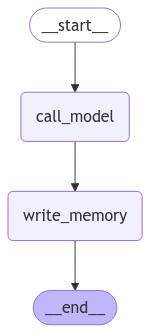

In [10]:
from IPython.display import Image, display

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.store.base import BaseStore

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.runnables.config import RunnableConfig

# Chatbot instruction
MODEL_SYSTEM_MESSAGE = """You are a helpful assistant with memory that provides information about the user. 
If you have memory for this user, use it to personalize your responses.
Here is the memory (it may be empty): {memory}"""

# Create new memory from the chat history and any existing memory
CREATE_MEMORY_INSTRUCTION = """"You are collecting information about the user to personalize your responses.

CURRENT USER INFORMATION:
{memory}

INSTRUCTIONS:
1. Review the chat history below carefully
2. Identify new information about the user, such as:
   - Personal details (name, location)
   - Preferences (likes, dislikes)
   - Interests and hobbies
   - Past experiences
   - Goals or future plans
3. Merge any new information with existing memory
4. Format the memory as a clear, bulleted list
5. If new information conflicts with existing memory, keep the most recent version

Remember: Only include factual information directly stated by the user. Do not make assumptions or inferences.

Based on the chat history below, please update the user information:"""

def call_model(state: MessagesState, config: RunnableConfig, store: BaseStore):

    """Load memory from the store and use it to personalize the chatbot's response."""
    
    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]

    # Retrieve memory from the store
    namespace = ("memory", user_id)
    key = "user_memory"
    existing_memory = store.get(namespace, key)

    # Extract the actual memory content if it exists and add a prefix
    if existing_memory:
        # Value is a dictionary with a memory key
        existing_memory_content = existing_memory.value.get('memory')
    else:
        existing_memory_content = "No existing memory found."

    # Format the memory in the system prompt
    system_msg = MODEL_SYSTEM_MESSAGE.format(memory=existing_memory_content)
    
    # Respond using memory as well as the chat history
    response = model.invoke([SystemMessage(content=system_msg)]+state["messages"])

    return {"messages": response}

def write_memory(state: MessagesState, config: RunnableConfig, store: BaseStore):

    """Reflect on the chat history and save a memory to the store."""
    
    # Get the user ID from the config
    user_id = config["configurable"]["user_id"]

    # Retrieve existing memory from the store
    namespace = ("memory", user_id)
    existing_memory = store.get(namespace, "user_memory")
        
    # Extract the memory
    if existing_memory:
        existing_memory_content = existing_memory.value.get('memory')
    else:
        existing_memory_content = "No existing memory found."

    # Format the memory in the system prompt
    system_msg = CREATE_MEMORY_INSTRUCTION.format(memory=existing_memory_content)
    new_memory = model.invoke([SystemMessage(content=system_msg)]+state['messages'])

    # Overwrite the existing memory in the store 
    key = "user_memory"

    # Write value as a dictionary with a memory key
    store.put(namespace, key, {"memory": new_memory.content})

# Define the graph
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_node("write_memory", write_memory)
builder.add_edge(START, "call_model")
builder.add_edge("call_model", "write_memory")
builder.add_edge("write_memory", END)

# Store for long-term (across-thread) memory
across_thread_memory = InMemoryStore()

# Checkpointer for short-term (within-thread) memory
within_thread_memory = MemorySaver()

# Compile the graph with the checkpointer fir and store
graph = builder.compile(checkpointer=within_thread_memory, store=across_thread_memory)

# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [11]:
# We supply a thread ID for short-term (within-thread) memory
# We supply a user ID for long-term (across-thread) memory 
config = {"configurable": {"thread_id": "1", "user_id": "1"}}

# User input 
input_messages = [HumanMessage(content="Hi, my name is Lance")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

Hi, my name is Lance
================================== Ai Message ==================================

Hello Lance! It's nice to meet you. Since we just started our conversation, I don't have any prior knowledge about you, but I'm happy to get to know you better. How can I assist you today?


In [12]:
# User input 
input_messages = [HumanMessage(content="I like to bike around San Francisco")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

I like to bike around San Francisco
================================== Ai Message ==================================

San Francisco is a great city for biking! There are many scenic routes and bike paths that offer stunning views of the city and its iconic landmarks. What's your favorite part about biking in San Francisco, Lance? Are you a fan of riding along the waterfront, exploring the hills of Haight-Ashbury, or visiting some of the city's famous parks like Golden Gate Park?


In [13]:
thread = {"configurable": {"thread_id": "1"}}
state = graph.get_state(thread).values
for m in state["messages"]: 
    m.pretty_print()

================================ Human Message =================================

Hi, my name is Lance
================================== Ai Message ==================================

Hello Lance! It's nice to meet you. Since we just started our conversation, I don't have any prior knowledge about you, but I'm happy to get to know you better. How can I assist you today?
================================ Human Message =================================

I like to bike around San Francisco
================================== Ai Message ==================================

San Francisco is a great city for biking! There are many scenic routes and bike paths that offer stunning views of the city and its iconic landmarks. What's your favorite part about biking in San Francisco, Lance? Are you a fan of riding along the waterfront, exploring the hills of Haight-Ashbury, or visiting some of the city's famous parks like Golden Gate Park?


In [14]:
# Namespace for the memory to save
user_id = "1"
namespace = ("memory", user_id)
existing_memory = across_thread_memory.get(namespace, "user_memory")
existing_memory.dict()

{'value': {'memory': ''},
 'key': 'user_memory',
 'namespace': ['memory', '1'],
 'created_at': '2024-12-20T11:36:58.064493+00:00',
 'updated_at': '2024-12-20T11:36:58.064494+00:00'}

In [15]:
# We supply a user ID for across-thread memory as well as a new thread ID
config = {"configurable": {"thread_id": "2", "user_id": "1"}}

# User input 
input_messages = [HumanMessage(content="Hi! Where would you recommend that I go biking?")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

Hi! Where would you recommend that I go biking?
================================== Ai Message ==================================

I don't have any specific memories of our previous conversations, but I'd be happy to help you find a great spot for biking!

There are many amazing places to bike, depending on your location and preferences. Here are a few suggestions:

1. **Local parks or trails**: Many cities have beautiful parks or trails that are perfect for biking. These areas often have smooth surfaces, scenic views, and minimal traffic.
2. **Beaches**: If you live near the coast, consider biking along the beachfront path. The ocean breeze, sand between your tires, and stunning views make for a unique and enjoyable ride.
3. **Mountain bike trails**: If you're an experienced biker or looking for a challenge, consider hitting some mountain bike trails. These areas often have steep inclines, technical terra

In [16]:
# User input 
input_messages = [HumanMessage(content="Great, are there any bakeries nearby that I can check out? I like a croissant after biking.")]

# Run the graph
for chunk in graph.stream({"messages": input_messages}, config, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

Great, are there any bakeries nearby that I can check out? I like a croissant after biking.
================================== Ai Message ==================================

A delicious croissant sounds like the perfect reward after a bike ride!

Unfortunately, I don't have any specific information about bakeries near you since we just started our conversation. However, I can suggest a few ways to find some great bakeries in your area:

1. **Online search**: You can try searching for "best bakeries near me" or "bakeries in [your city/region]" on your favorite search engine (e.g., Google).
2. **Yelp or TripAdvisor**: These review websites often have lists of top-rated bakeries and cafes in various locations.
3. **Ask locals**: If you know someone who lives nearby, ask them for recommendations! They might be able to point you in the direction of a fantastic bakery.

If you'd like, I can also try to help you